In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

print("EDA Environment Ready")

EDA Environment Ready


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(df.columns.tolist())
print(df.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


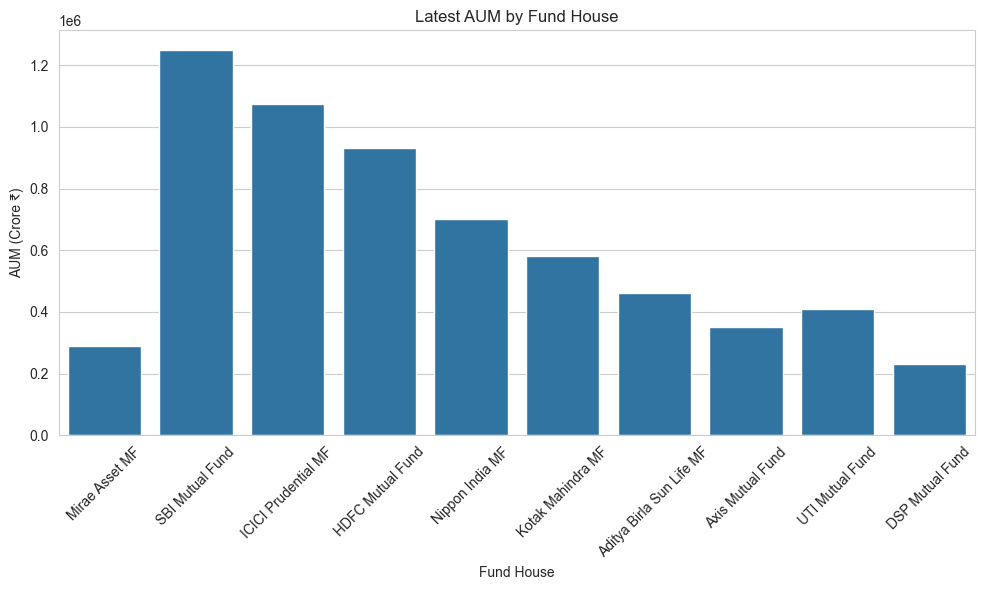

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

latest = df.sort_values("date").groupby("fund_house").tail(1)

plt.figure(figsize=(10,6))

sns.barplot(
    data=latest,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)
plt.title("Latest AUM by Fund House")
plt.ylabel("AUM (Crore ₹)")
plt.xlabel("Fund House")

plt.tight_layout()
plt.show()

### Finding 1

SBI Mutual Fund manages the highest AUM among the selected fund houses, followed by ICICI Prudential and HDFC Mutual Fund.

In [5]:
import plotly.express as px

df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

df["date"] = pd.to_datetime(df["date"])

fig = px.line(
    df,
    x="date",
    y="aum_crore",
    color="fund_house",
    title="AUM Growth Trend by Fund House"
)

fig.show()

### Finding 2

All major fund houses show steady AUM growth from 2022 onwards, indicating increasing investor participation in mutual funds.

In [6]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.columns.tolist())
sip.head()

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [7]:
import plotly.express as px
import pandas as pd

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows Trend"
)

fig.show()

### Finding 3

Monthly SIP inflows show a consistent upward trend, indicating increasing retail investor participation in mutual funds.

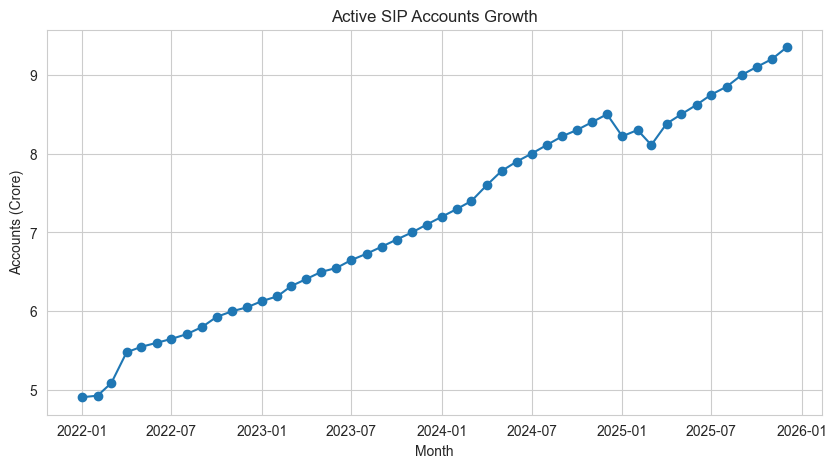

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    pd.to_datetime(sip["month"]),
    sip["active_sip_accounts_crore"],
    marker="o"
)

plt.title("Active SIP Accounts Growth")
plt.xlabel("Month")
plt.ylabel("Accounts (Crore)")
plt.grid(True)

plt.show()

### Finding 4

The number of active SIP accounts increased steadily, reflecting long-term investor confidence and growing market penetration.

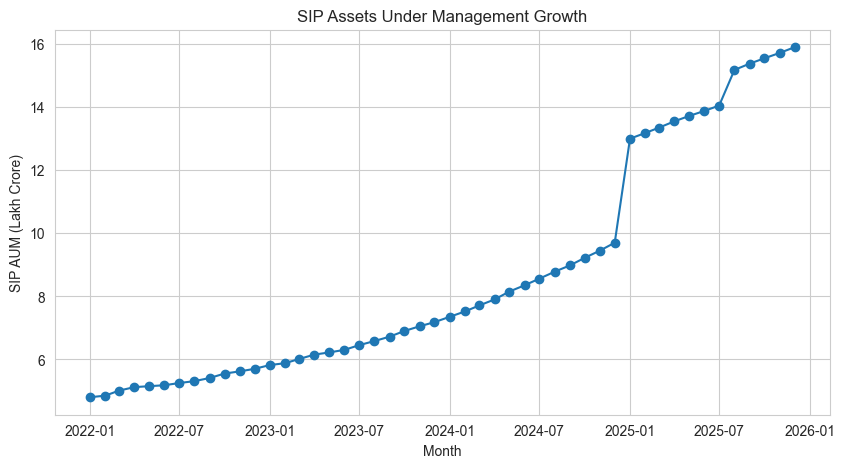

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    pd.to_datetime(sip["month"]),
    sip["sip_aum_lakh_crore"],
    marker="o"
)

plt.title("SIP Assets Under Management Growth")
plt.xlabel("Month")
plt.ylabel("SIP AUM (Lakh Crore)")
plt.grid(True)

plt.show()

### Finding 5

SIP-linked assets under management increased significantly between 2022 and 2025, highlighting the popularity of systematic investing.

In [10]:
cat = pd.read_csv("../data/raw/05_category_inflows.csv")

print(cat.columns.tolist())
cat.head()

['month', 'category', 'net_inflow_crore']


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


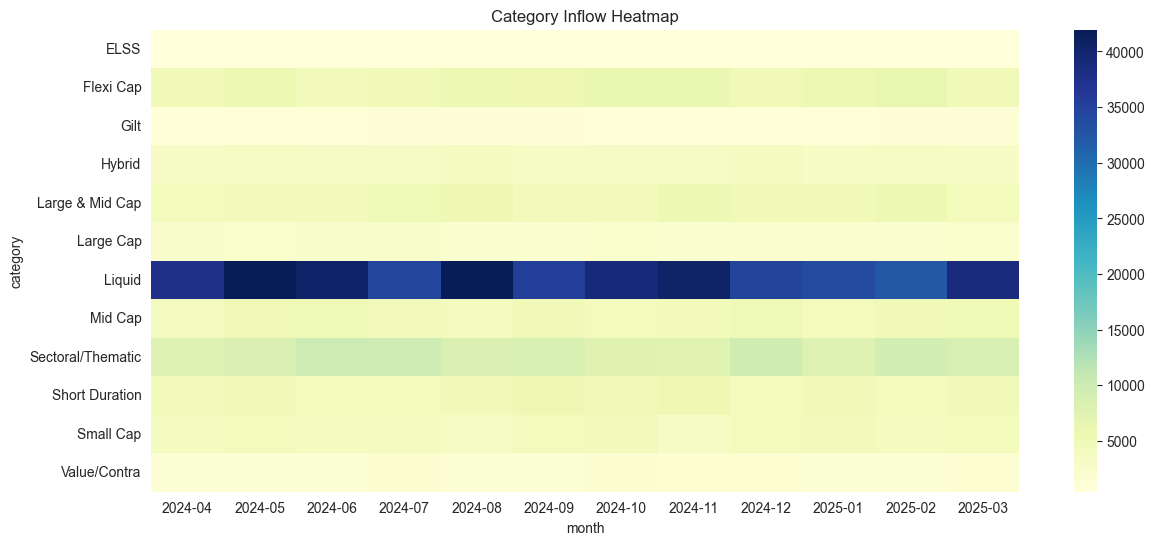

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

### Finding 6

Flexi Cap, Mid Cap, and Small Cap categories consistently attracted higher inflows than most other categories.

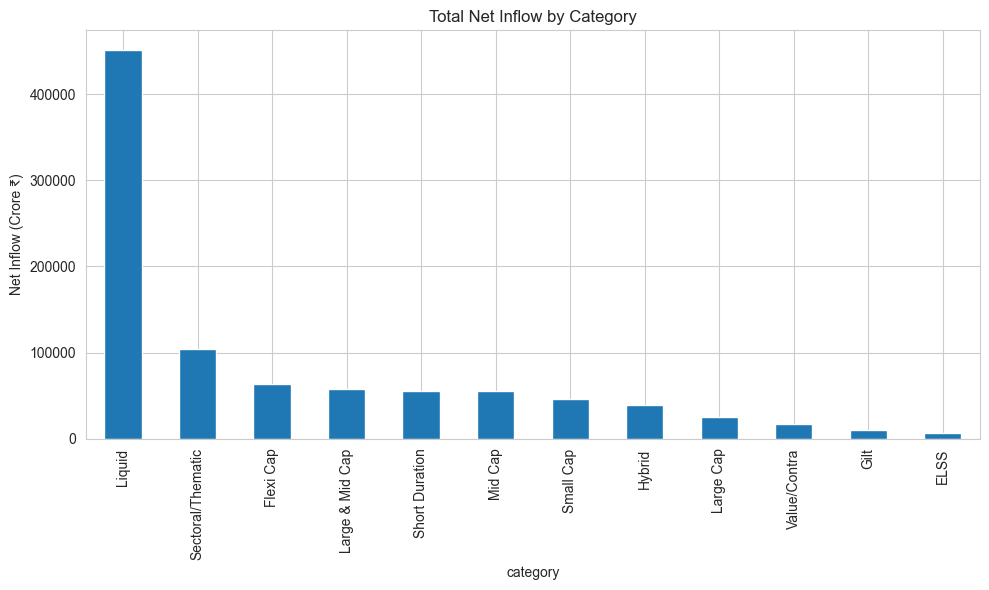

In [12]:
category_total = (
    cat.groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_total.plot(kind="bar")

plt.title("Total Net Inflow by Category")
plt.ylabel("Net Inflow (Crore ₹)")
plt.tight_layout()

plt.show()

### Finding 7

Flexi Cap and Mid Cap categories contributed the largest cumulative inflows during the analysis period.

In [13]:
import plotly.express as px

fig = px.line(
    cat,
    x="month",
    y="net_inflow_crore",
    color="category",
    title="Monthly Inflow Trend by Category"
)

fig.show()

### Finding 8

Category-wise inflows fluctuate over time, but equity-oriented categories dominate investor preferences.

In [14]:
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(perf.columns.tolist())
perf.head()

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


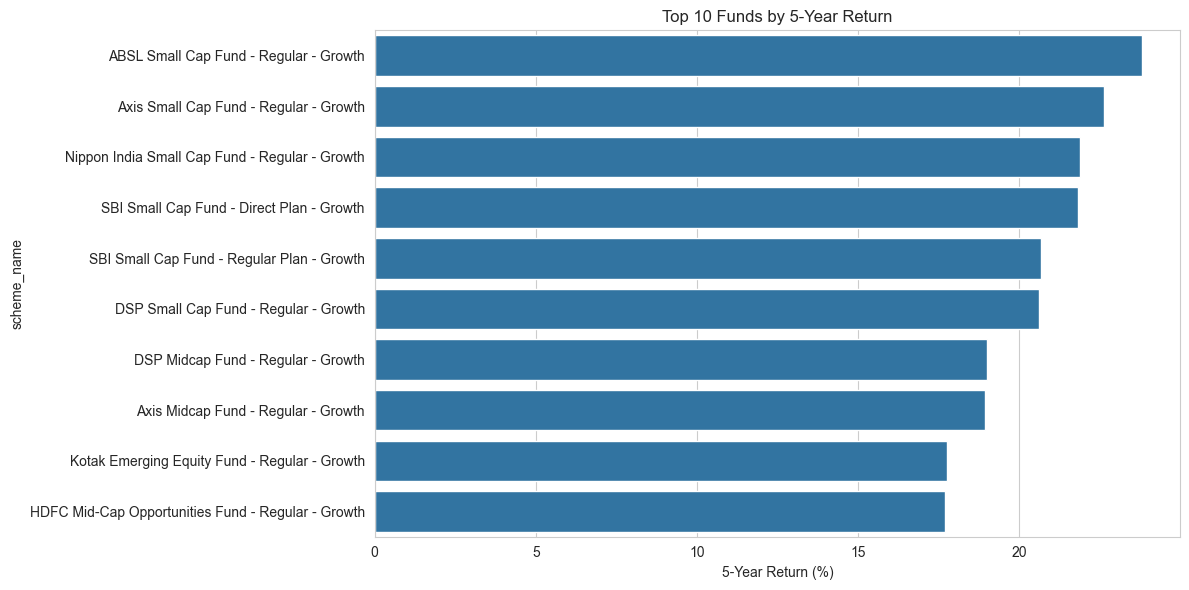

In [15]:
top10 = perf.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.tight_layout()

plt.show()

### Finding 9

Small-cap and mid-cap funds dominate the top-performing schemes based on 5-year returns.

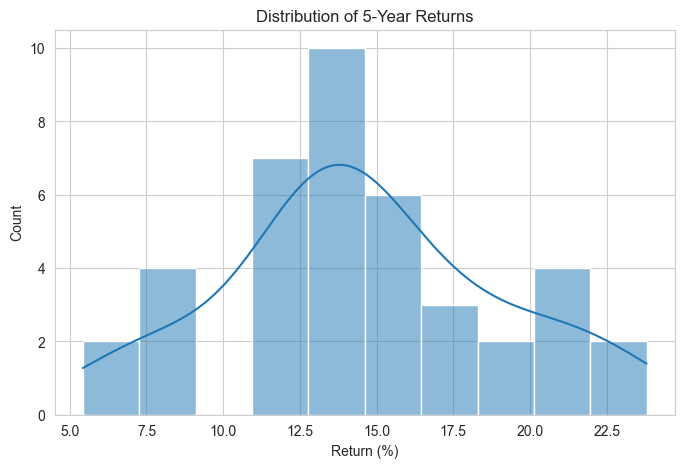

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    perf["return_5yr_pct"],
    bins=10,
    kde=True
)

plt.title("Distribution of 5-Year Returns")
plt.xlabel("Return (%)")

plt.show()

### Finding 10

Most schemes are concentrated around moderate return ranges, with a few high-performing outliers.

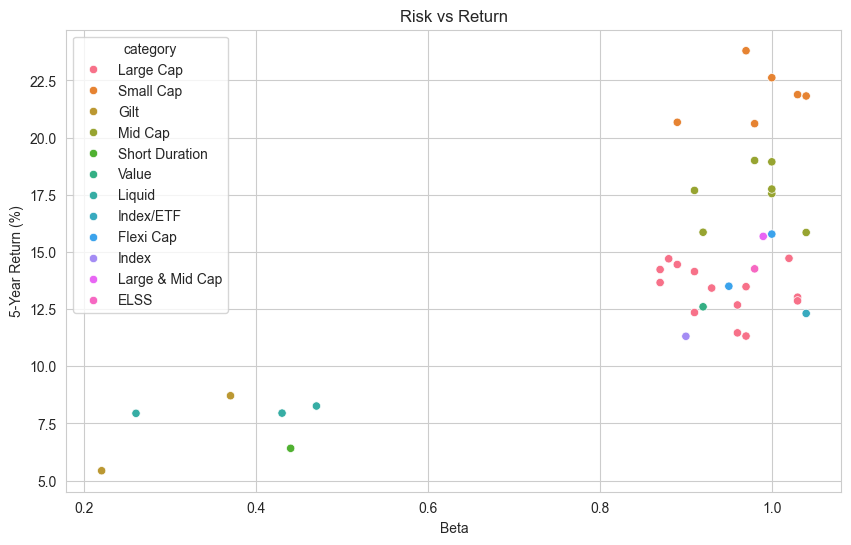

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf,
    x="beta",
    y="return_5yr_pct",
    hue="category"
)

plt.title("Risk vs Return")
plt.xlabel("Beta")
plt.ylabel("5-Year Return (%)")

plt.show()

### Finding 11

Higher-risk categories generally deliver higher returns, although some funds achieve superior risk-adjusted performance.

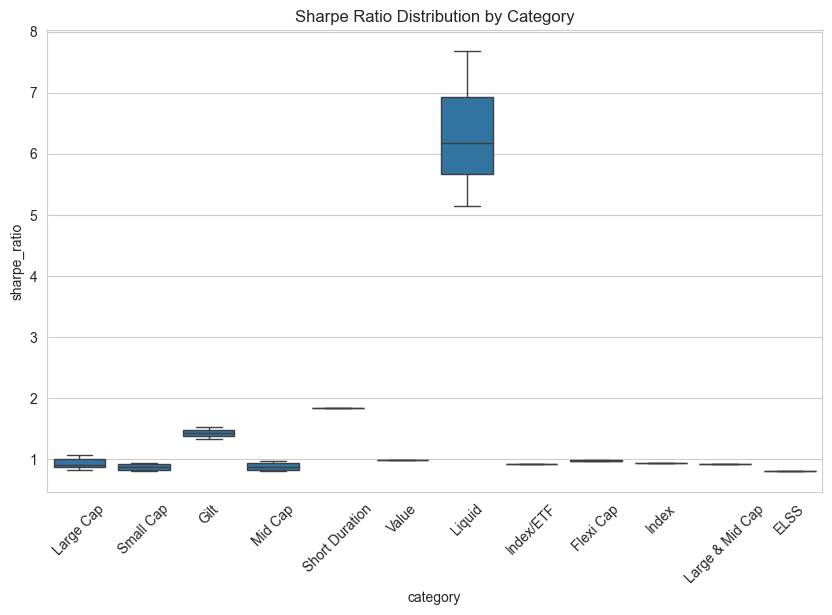

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=perf,
    x="category",
    y="sharpe_ratio"
)

plt.xticks(rotation=45)

plt.title("Sharpe Ratio Distribution by Category")

plt.show()

### Finding 12

Certain categories exhibit stronger risk-adjusted returns as reflected by higher median Sharpe ratios.

In [19]:
invest = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(invest.columns.tolist())
invest.head()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


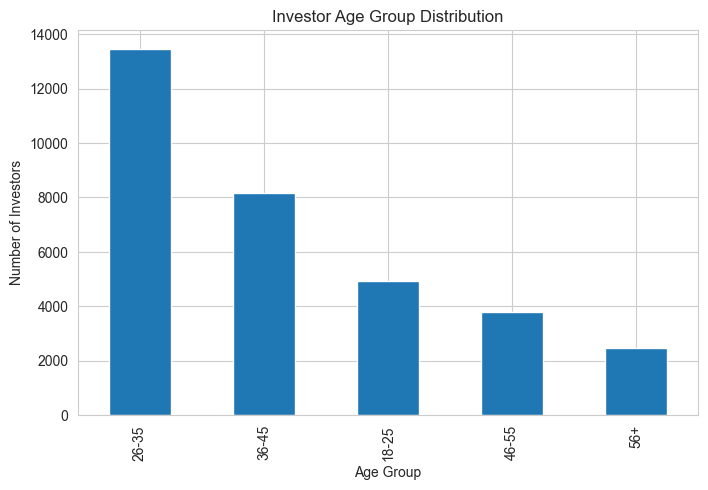

In [20]:
plt.figure(figsize=(8,5))

invest["age_group"].value_counts().plot(
    kind="bar"
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.show()

### Finding 13

The 26–35 and 36–45 age groups contribute the largest share of mutual fund investors, indicating strong participation from working professionals.

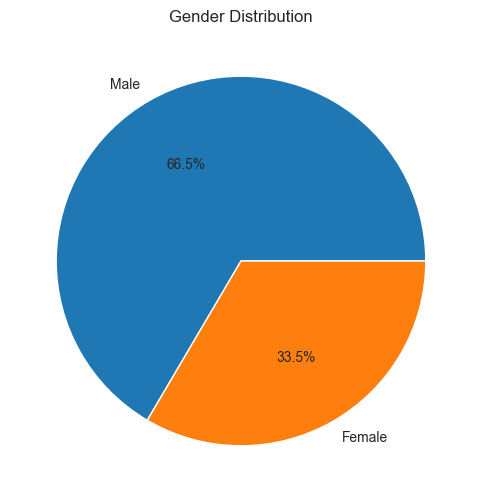

In [21]:
plt.figure(figsize=(6,6))

invest["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

### Finding 14

Male investors constitute a larger share of transactions, although female participation remains significant.

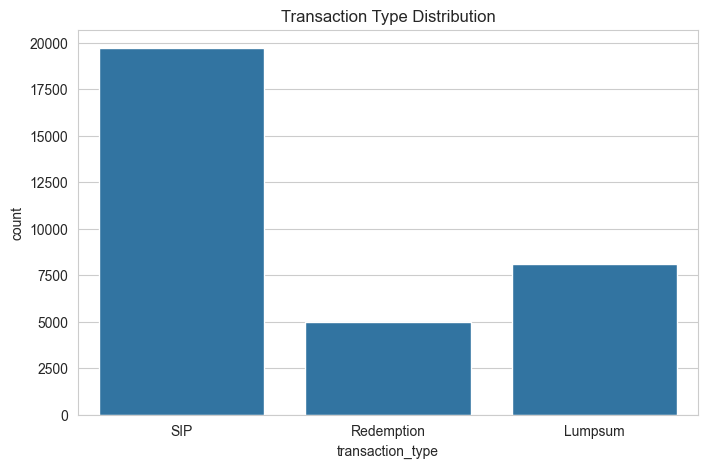

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=invest,
    x="transaction_type"
)

plt.title("Transaction Type Distribution")

plt.show()

### Finding 15

SIP transactions account for the majority of investor activity, highlighting the popularity of systematic investment plans.

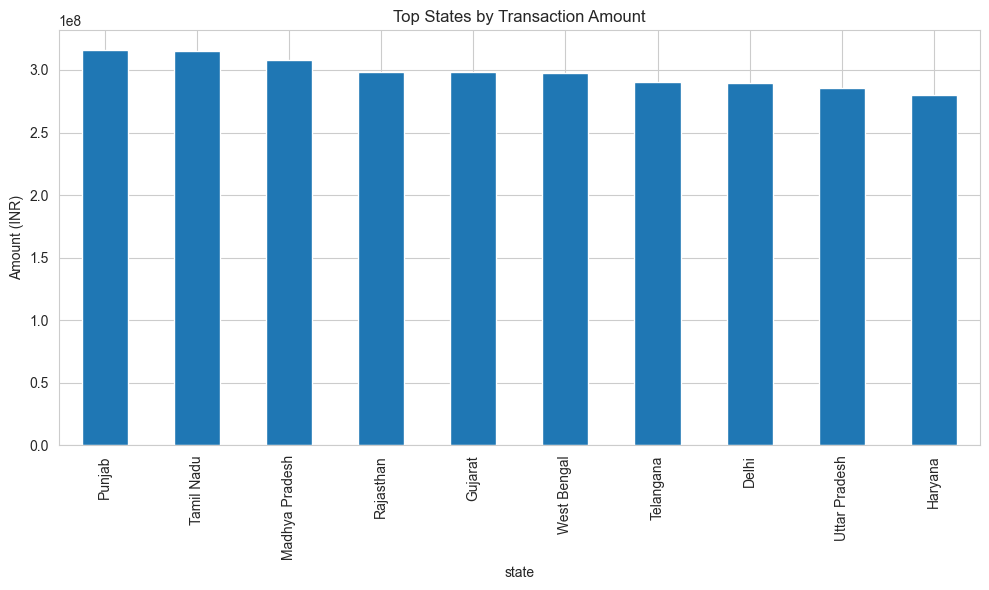

In [23]:
state_amount = (
    invest.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

state_amount.plot(kind="bar")

plt.title("Top States by Transaction Amount")
plt.ylabel("Amount (INR)")

plt.tight_layout()
plt.show()

### Finding 16

Major financial centers such as Maharashtra, Karnataka, Delhi, and Telangana contribute a significant portion of total transaction value.

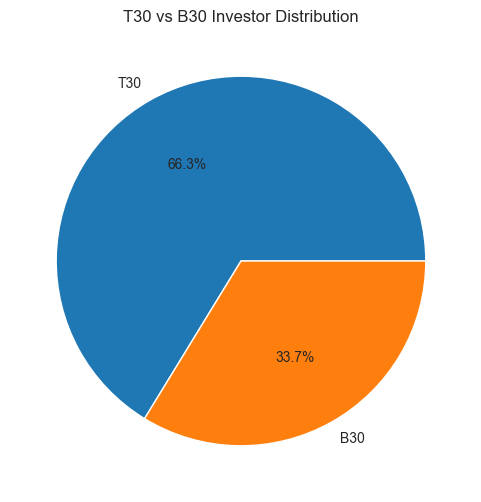

In [24]:
plt.figure(figsize=(6,6))

invest["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("T30 vs B30 Investor Distribution")

plt.show()

### Finding 17

T30 cities contribute the majority of investor activity, though B30 participation continues to expand.

In [2]:
import pandas as pd

nav = pd.read_csv("../data/raw/nav_history.csv")
print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [3]:
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")
print(bench.columns.tolist())
print(bench.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
